# GFDL-ESM4 — MLR: FWI vs. 4 Climate Drivers (Thailand)

**Sections 1–5** (dependencies, configuration, data loading, area weights, helpers)
are taken directly from `GFDL-ESM4_FWI_4drivers.ipynb`.  
**Sections 6–10** contain the Multiple Linear Regression analysis.

| Variable | Units (raw) | Grid |
|---|---|---|
| `fwisa` | dimensionless | 0.25° × 0.25° (annual) |
| `tasmax` | K | ~1° × 1° (monthly) |
| `pr` | kg m⁻² s⁻¹ | ~1° × 1° (monthly) |
| `sfcWind` | m s⁻¹ | ~1° × 1° (monthly) |
| `hurs` | % | ~1° × 1° (monthly) |

> Set `DATA_ROOT` in **Section 2** to your local data directory.

## 1  Dependencies

In [3]:
# Standard library
from pathlib import Path

# Third-party
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import linregress
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import zscore
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

## 2  Configuration

Edit `DATA_ROOT` to match your local data directory, then run all cells.


In [5]:
# ── User configuration ───────────────────────────────────────────────────────
DATA_ROOT = Path("/Volumes/jubjang/Jubjang")   # <-- change this if needed

OUTPUT_FILE = "Pict/FWI_vs_4drivers_Thailand_2x2.png"

# Study region: Thailand
TH_SLICE = dict(lat=slice(5.5, 20.5), lon=slice(97.5, 105.5))

# Scenario identifiers
SCENARIOS = ["historical", "ssp119", "ssp126", "ssp245", "ssp370", "ssp585"]

# Display labels (used in legend)
SCENARIO_LABELS = {
    "historical": "Historical",
    "ssp119":     "SSP1-1.9",
    "ssp126":     "SSP1-2.6",
    "ssp245":     "SSP2-4.5",
    "ssp370":     "SSP3-7.0",
    "ssp585":     "SSP5-8.5",
}

# Colour-blind-friendly palette (Wong, 2011)
PALETTE = {
    "historical": "#000000",
    "ssp119":     "#E69F00",
    "ssp126":     "#56B4E9",
    "ssp245":     "#009E73",
    "ssp370":     "#882255",
    "ssp585":     "#CC79A7",
}


In [6]:
## 6.  Build panel_df_th from precomputed cache
# ── Loads the same per-scenario 1-D DataArrays saved by GFDL-ESM4_FWI_4drivers
# ── No raw data access, no resampling, no area weighting — already done.
from pathlib import Path
CACHE_DIR = Path("/Users/thunthita/ClimateChangeonWildfire/new/src/GFDL_ESM4/computed_means_GFDL-ESM4")

def _load(var_name):
    return {
        s: xr.open_dataarray(CACHE_DIR / f"{var_name}_{s}.nc").load()
        for s in SCENARIOS
        if (CACHE_DIR / f"{var_name}_{s}.nc").exists()
    }

fwi_means     = _load("fwi")
tasmax_means  = _load("tasmax")
pr_means      = _load("pr")
sfcWind_means = _load("sfcWind")
hurs_means    = _load("hurs")

rows = []
for scen in SCENARIOS:
    fwi_da = fwi_means[scen]
    t      = fwi_da["year"]
    rows.append(pd.DataFrame({
        "time"    : t.values.astype(int),
        "FWI"     : fwi_da.values,
        "tasmax"  : (tasmax_means[scen].sel(year=t, method="nearest") - 273.15  ).values,
        "pr"      : (pr_means[scen].sel(   year=t, method="nearest") * 86_400.0).values,
        "sfcWind" : sfcWind_means[scen].sel(year=t, method="nearest").values,
        "hurs"    : hurs_means[scen].sel(   year=t, method="nearest").values,
        "scenario": SCENARIO_LABELS[scen],
    }))

panel_df_th = pd.concat(rows, ignore_index=True)
for c in ["FWI", "tasmax", "pr", "hurs", "sfcWind"]:
    panel_df_th[c] = pd.to_numeric(panel_df_th[c], errors="coerce")
panel_df_th.replace([np.inf, -np.inf], np.nan, inplace=True)
panel_df_th.dropna(subset=["FWI", "tasmax", "pr", "hurs", "sfcWind"], inplace=True)
panel_df_th["time"]     = panel_df_th["time"].astype(int)
panel_df_th["scenario"] = panel_df_th["scenario"].astype(object)

print(panel_df_th.head())
print()
print("Rows per scenario:")
print(panel_df_th.groupby("scenario").size())

   time        FWI     tasmax        pr   sfcWind       hurs    scenario
0  1850  16.446996  27.783996  5.454123  2.844883  78.443607  Historical
1  1851  11.380531  26.869837  6.127192  2.820498  82.168921  Historical
2  1852  25.823938  28.371919  4.394625  2.845783  75.660264  Historical
3  1853  26.306468  28.255532  5.306636  2.860889  76.664529  Historical
4  1854  12.236745  26.912593  5.404293  2.822148  81.221764  Historical

Rows per scenario:
scenario
Historical    165
SSP1-1.9       86
SSP1-2.6       86
SSP2-4.5       86
SSP3-7.0       86
SSP5-8.5       86
dtype: int64


## 7. OLS Multiple Linear Regression

Fits: `FWI ~ tasmax + pr + hurs + sfcWind [+ C(scenario)]`

- HC1 heteroskedasticity-robust standard errors are used.
- Scenario fixed effects are added automatically when ≥ 2 scenarios are present.

In [8]:
assert 'panel_df_th' in globals() and len(panel_df_th) > 0, \
    "panel_df_th is missing or empty — run Section 6 first."

# --- OLS formula (with scenario fixed effects if multi-scenario) ---
use_fe  = panel_df_th['scenario'].nunique() >= 2
formula = 'FWI ~ tasmax + pr + hurs + sfcWind' + (' + C(scenario)' if use_fe else '')
print('Formula:', formula)

# --- Fit with HC1 robust SEs ---
mlr_model = smf.ols(formula, data=panel_df_th).fit(cov_type='HC1')
print(mlr_model.summary())


Formula: FWI ~ tasmax + pr + hurs + sfcWind + C(scenario)
                            OLS Regression Results                            
Dep. Variable:                    FWI   R-squared:                       0.834
Model:                            OLS   Adj. R-squared:                  0.832
Method:                 Least Squares   F-statistic:                     372.8
Date:                Tue, 21 Apr 2026   Prob (F-statistic):          1.07e-235
Time:                        15:06:43   Log-Likelihood:                -1204.9
No. Observations:                 595   AIC:                             2430.
Df Residuals:                     585   BIC:                             2474.
Df Model:                           9                                         
Covariance Type:                  HC1                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------

## 8. Standardised (Beta) Coefficients

All continuous variables are z-scored so coefficients are directly comparable
in units of standard deviations.

In [10]:
# Z-score continuous variables only (not the categorical scenario)
to_z   = ['FWI', 'tasmax', 'pr', 'hurs', 'sfcWind']
df_std = panel_df_th.copy()
df_std[to_z] = df_std[to_z].apply(zscore)

mlr_model_beta = smf.ols(formula, data=df_std).fit(cov_type='HC1')

print('=== Standardised (beta) coefficients ===')
print(mlr_model_beta.params[['tasmax', 'pr', 'hurs', 'sfcWind']])
print()
print('Positive beta => variable increases as FWI increases')
print('Negative beta => inverse relationship with FWI')

# --- Full coefficient table (HC1 SE, t, p, 95% CI) ---
coef_table = pd.DataFrame({
    'coef'   : mlr_model.params,
    'HC1_se' : mlr_model.bse,
    't'      : mlr_model.tvalues,
    'pvalue' : mlr_model.pvalues,
})
coef_table['CI_low']  = coef_table['coef'] - 1.96 * coef_table['HC1_se']
coef_table['CI_high'] = coef_table['coef'] + 1.96 * coef_table['HC1_se']
print()
print('=== Coefficients table (HC1) ===')
print(coef_table.round(4))


=== Standardised (beta) coefficients ===
tasmax     0.071005
pr         0.165438
hurs      -0.970951
sfcWind    0.010424
dtype: float64

Positive beta => variable increases as FWI increases
Negative beta => inverse relationship with FWI

=== Coefficients table (HC1) ===
                             coef   HC1_se        t  pvalue    CI_low  \
Intercept                198.0699  10.5019  18.8605  0.0000  177.4862   
C(scenario)[T.SSP1-1.9]   -1.4546   0.2862  -5.0817  0.0000   -2.0157   
C(scenario)[T.SSP1-2.6]   -1.1726   0.2943  -3.9842  0.0001   -1.7495   
C(scenario)[T.SSP2-4.5]   -0.8392   0.3244  -2.5873  0.0097   -1.4749   
C(scenario)[T.SSP3-7.0]    0.2455   0.3812   0.6439  0.5196   -0.5017   
C(scenario)[T.SSP5-8.5]   -1.1272   0.3782  -2.9801  0.0029   -1.8685   
tasmax                     0.3321   0.1571   2.1133  0.0346    0.0241   
pr                         1.7368   0.2404   7.2232  0.0000    1.2655   
hurs                      -2.5228   0.0767 -32.8874  0.0000   -2.6731   

## 9. Diagnostic Plots

Visual checks for model fit quality.

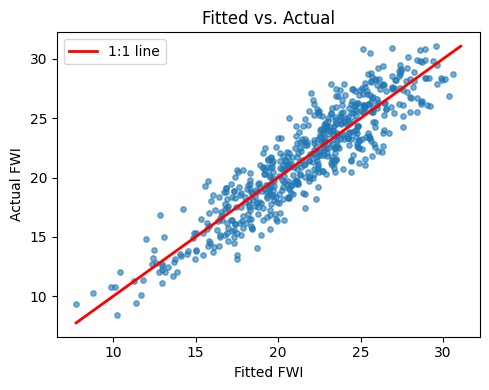

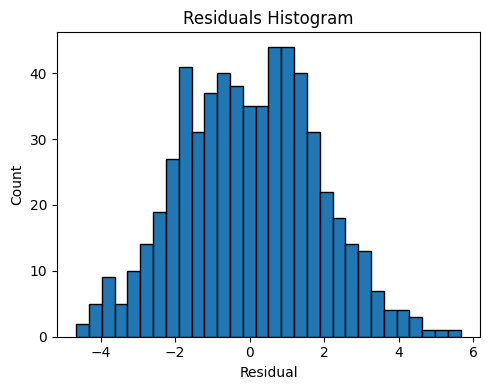

In [12]:
y     = panel_df_th['FWI'].values
yhat  = mlr_model.fittedvalues.values
resid = mlr_model.resid.values

# --- Fitted vs Actual ---
plt.figure(figsize=(5, 4))
plt.scatter(yhat, y, s=15, alpha=0.6)
mn, mx = np.min([y, yhat]), np.max([y, yhat])
plt.plot([mn, mx], [mn, mx], lw=2, color='red', label='1:1 line')
plt.xlabel('Fitted FWI')
plt.ylabel('Actual FWI')
plt.title('Fitted vs. Actual')
plt.legend()
plt.tight_layout()
plt.show()

# --- Residuals histogram ---
plt.figure(figsize=(5, 4))
plt.hist(resid, bins=30, edgecolor='black')
plt.xlabel('Residual')
plt.ylabel('Count')
plt.title('Residuals Histogram')
plt.tight_layout()
plt.show()


## 10. Variance Inflation Factors (VIF)

VIF > 10 typically indicates problematic multicollinearity.

In [14]:
cols          = ['FWI', 'tasmax', 'pr', 'hurs', 'sfcWind']
panel_df_clean = panel_df_th.dropna(subset=cols).copy()

X = panel_df_clean[['tasmax', 'pr', 'hurs', 'sfcWind']]
X = add_constant(X)

vif_data = pd.DataFrame({
    'Variable': X.columns,
    'VIF'     : [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
})
print(vif_data.round(2))


  Variable      VIF
0    const  9668.56
1   tasmax     1.64
2       pr     1.46
3     hurs     2.25
4  sfcWind     1.19
